In [61]:
import nrrd 
data, header = nrrd.read(r"D:\Project\ACL\Thuan dot 1\NGUYEN TAN TAI (25116149)\15 t2_tse_sag.nrrd")
print(data.shape)
print(header)

(608, 608, 25)
OrderedDict([('type', 'unsigned short'), ('dimension', 3), ('space', 'left-posterior-superior'), ('sizes', array([608, 608,  25])), ('space directions', array([[ 6.06554803e-02,  2.56050119e-01, -5.78697373e-03],
       [ 2.47780838e-03, -6.53343686e-03, -2.63107230e-01],
       [-3.50293750e+00,  8.28600000e-01, -5.35625000e-02]])), ('kinds', ['domain', 'domain', 'domain']), ('endian', 'little'), ('encoding', 'gzip'), ('space origin', array([ 51.1339, -91.5107,  52.0514]))])


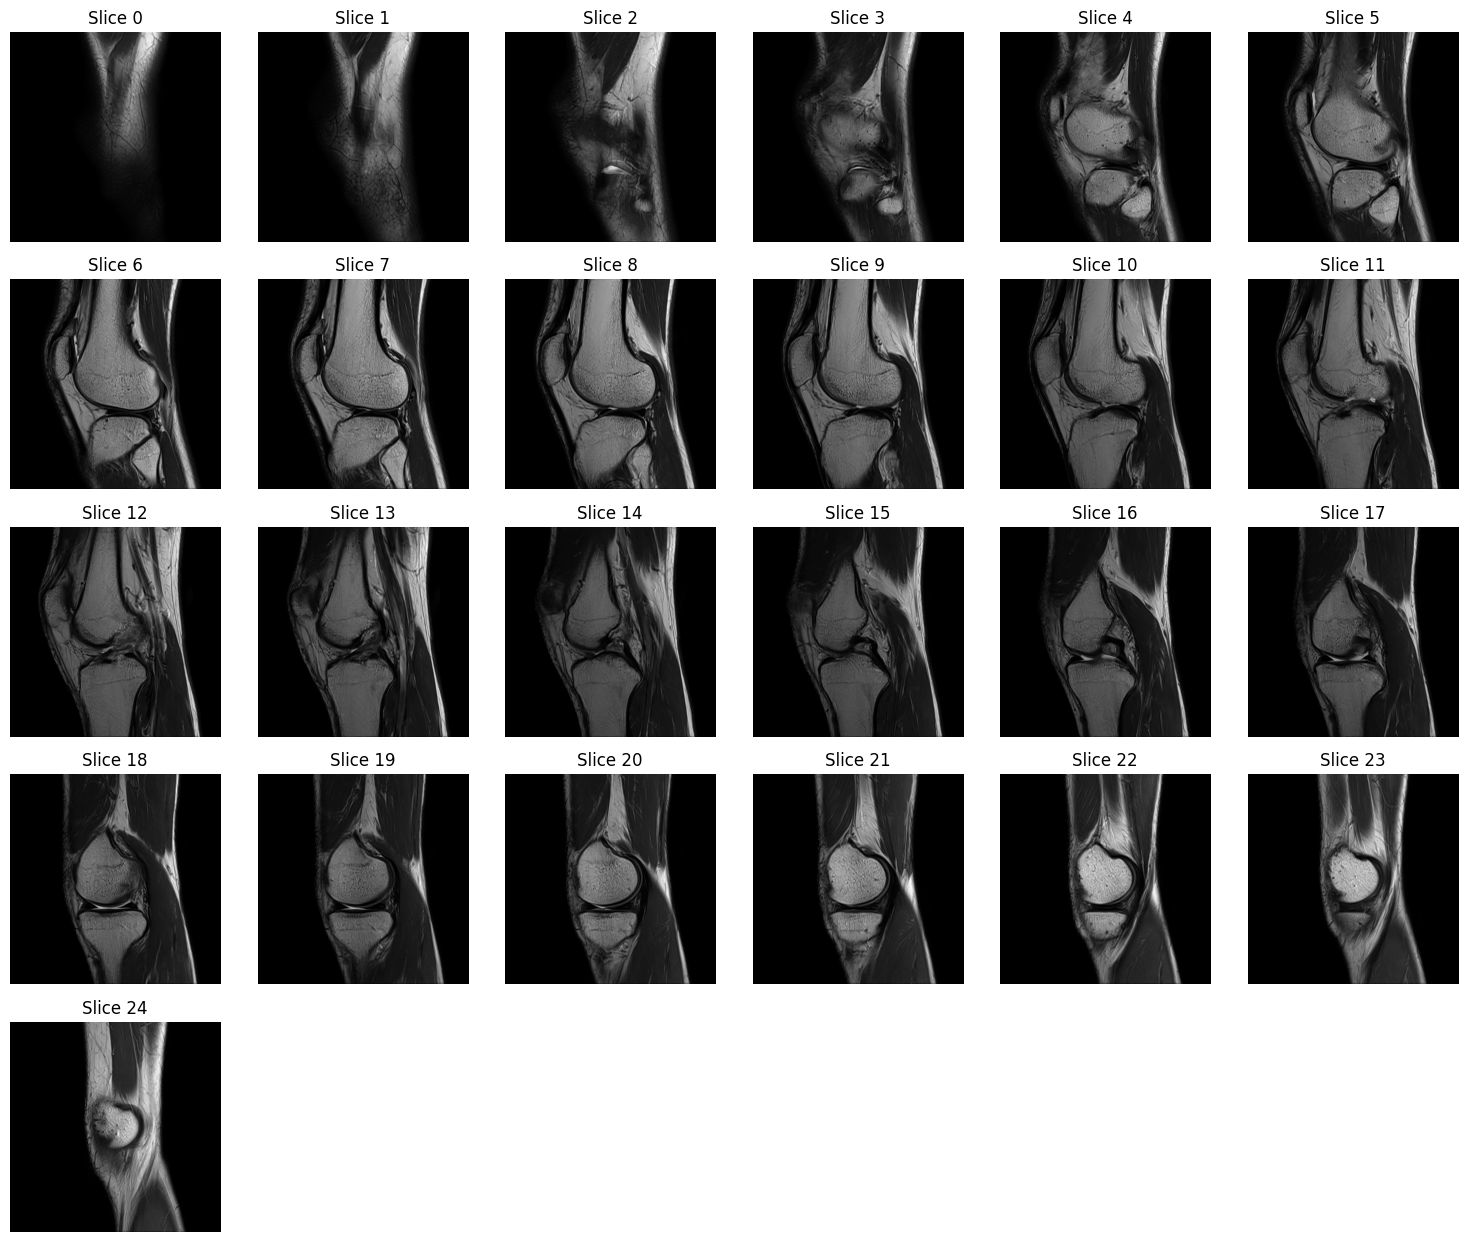

In [62]:
import matplotlib.pyplot as plt
import numpy as np
num_slices=25
plt.figure(figsize=(15, 15))
for i in range(num_slices):
    plt.subplot(6,6,i+1)
    slice_image=data[:,:,i]
    rotated_image = np.rot90(slice_image,k=3)
    flipped_image = np.fliplr(rotated_image)
    plt.imshow(flipped_image, cmap='gray')
    plt.title(f'Slice {i}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [66]:
seg_data,seg_header=nrrd.read(r"D:\Project\ACL\Thuan dot 1\NGUYEN TAN TAI (25116149)\Segmentation.seg.nrrd")
print(seg_data.shape)
print(seg_header)

(608, 608, 25)
OrderedDict([('type', 'unsigned char'), ('dimension', 3), ('space', 'left-posterior-superior'), ('sizes', array([608, 608,  25])), ('space directions', array([[ 6.06554803e-02,  2.56050119e-01, -5.78697373e-03],
       [ 2.47780838e-03, -6.53343686e-03, -2.63107230e-01],
       [-3.50293750e+00,  8.28600000e-01, -5.35625000e-02]])), ('kinds', ['domain', 'domain', 'domain']), ('encoding', 'gzip'), ('space origin', array([ 51.1339, -91.5107,  52.0514])), ('Segment0_Color', '0.501961 0.682353 0.501961'), ('Segment0_ColorAutoGenerated', '1'), ('Segment0_Extent', '261 367 298 385 12 14'), ('Segment0_ID', '2.25.4027062157554748894172976553134323870'), ('Segment0_LabelValue', '1'), ('Segment0_Layer', '0'), ('Segment0_Name', 'Dut_hoan_toan_1_3_tren'), ('Segment0_NameAutoGenerated', '0'), ('Segment0_Tags', 'TerminologyEntry:Segmentation category and type - 3D Slicer General Anatomy list~SCT^85756007^Tissue~SCT^85756007^Tissue~^^~Anatomic codes - DICOM master list~^^~^^|'), ('Segm

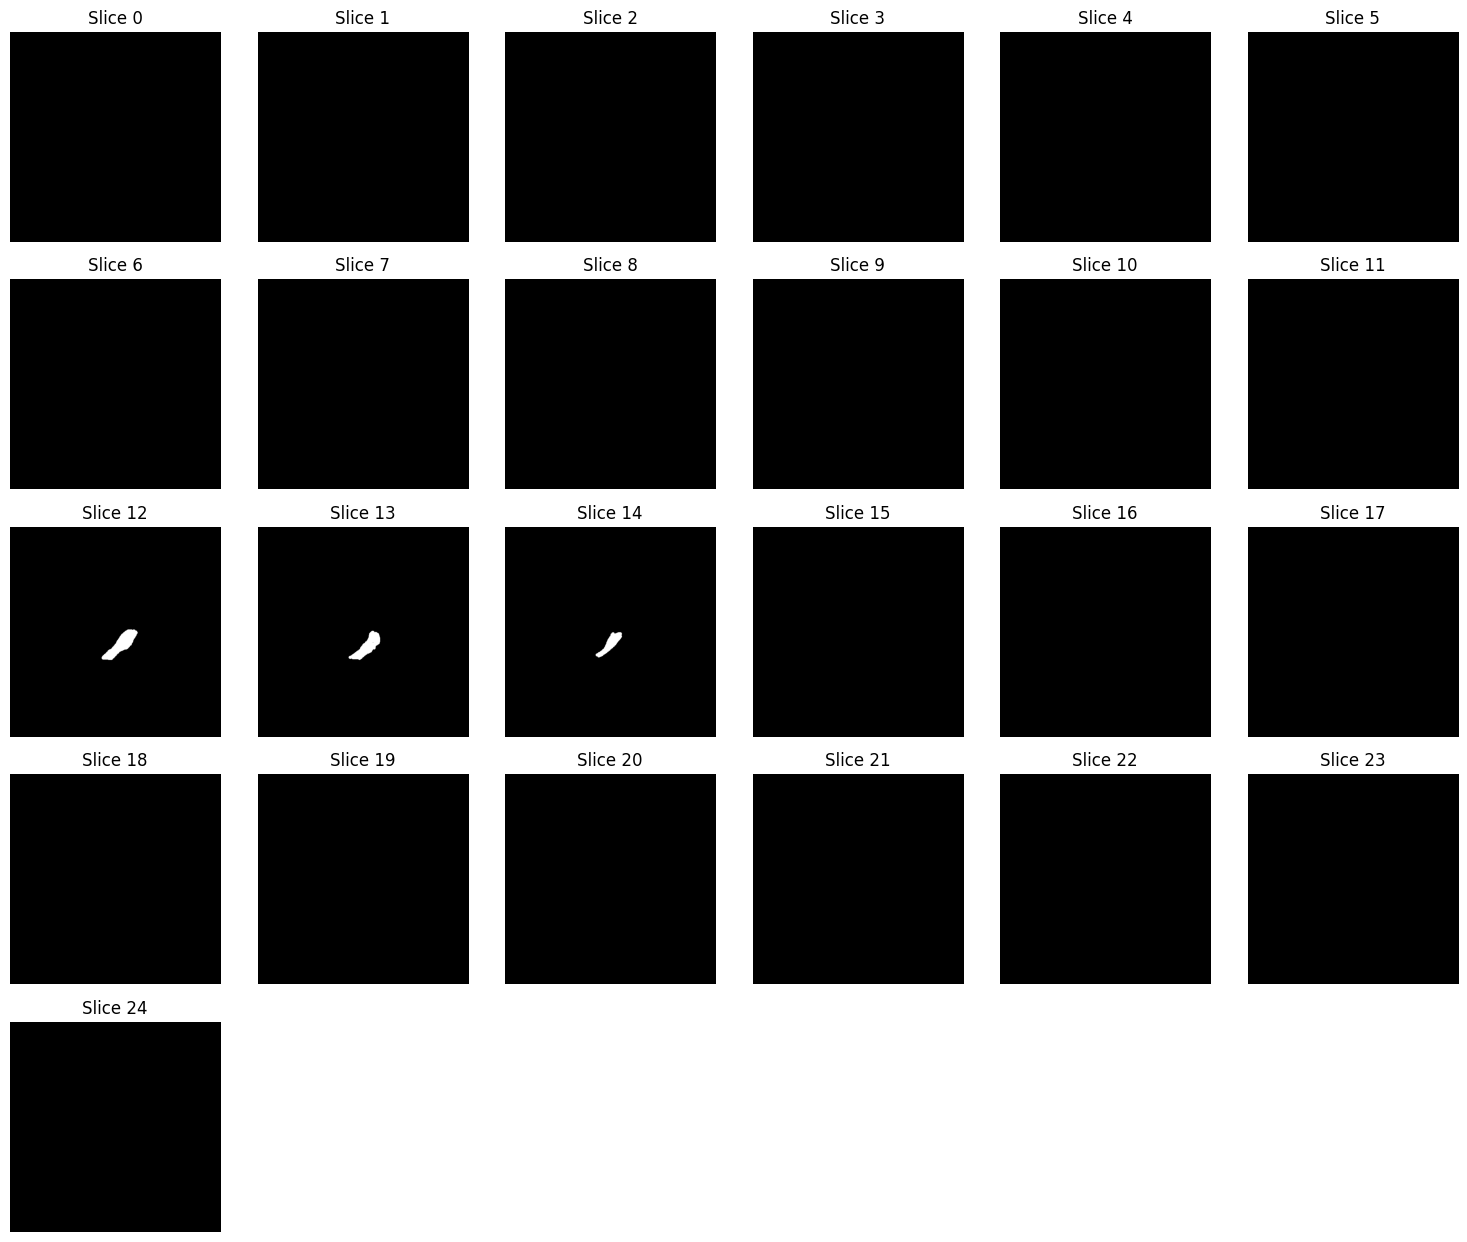

In [ ]:
num_slices=25
plt.figure(figsize=(15, 15))
for i in range(num_slices):
    plt.subplot(6,6,i+1)
    slice_image=seg_data[:,:,i]
    rotated_image = np.rot90(slice_image,k=3)
    flipped_image = np.fliplr(rotated_image)
    plt.imshow(flipped_image, cmap='gray')
    plt.title(f'Slice {i}')
    plt.axis('off')
plt.tight_layout()
plt.show()

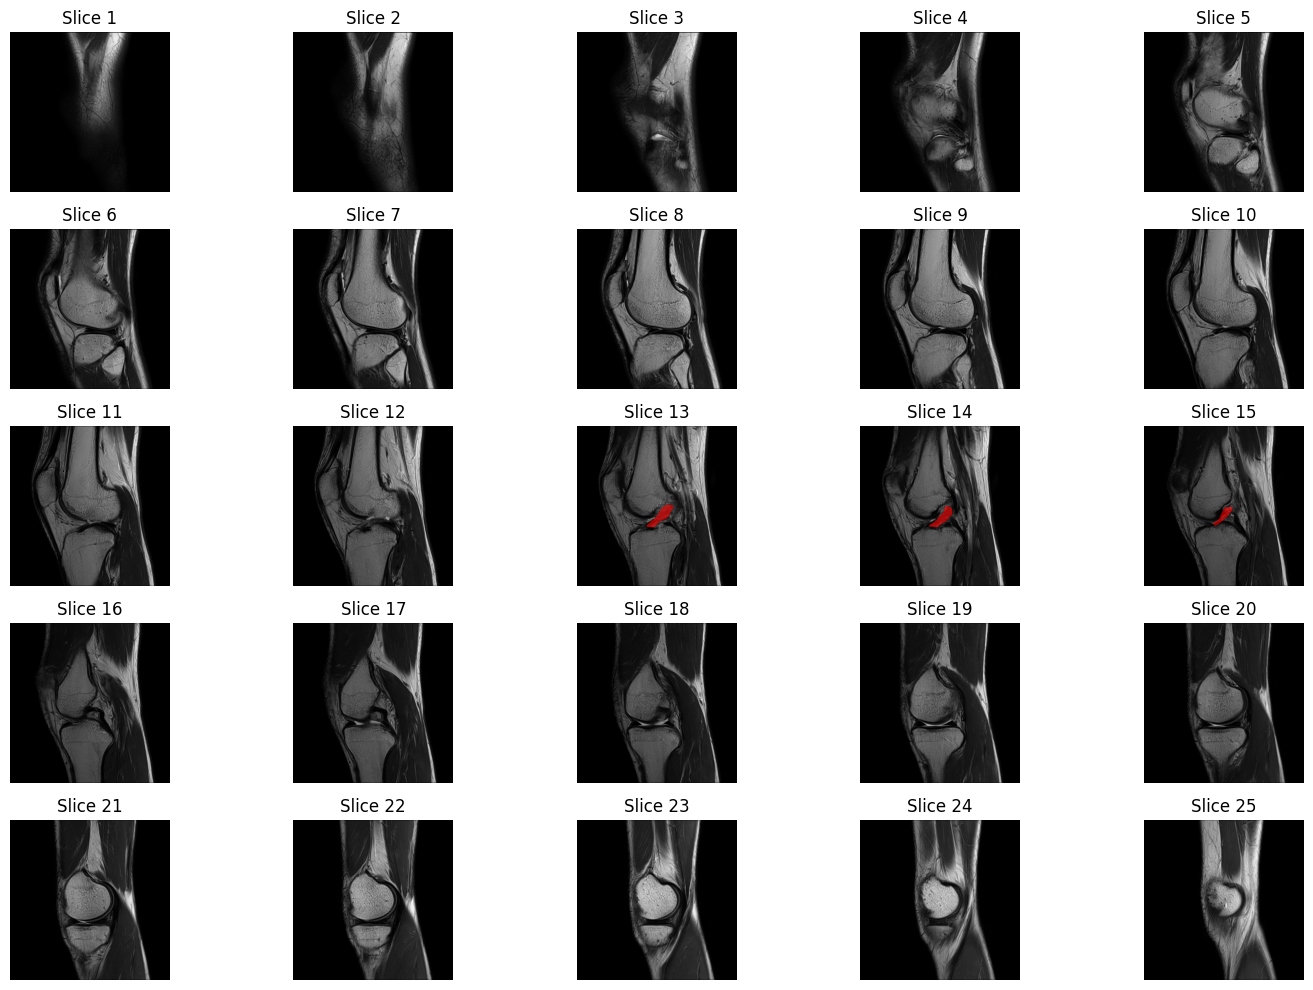

In [72]:
from matplotlib.colors import ListedColormap
def flip_image(image):
    rotated_image = np.rot90(image, k=3)
    flipped_image = np.fliplr(rotated_image)
    return flipped_image
cmap = ListedColormap([
    (0, 0, 0, 0),       # class 0 → transparent
    (1, 0, 0, 0.6),     # class 1 → red
    (1, 1, 0, 0.6),     # class 2 → green
    (1, 0, 0, 0.6)      # class 3 → yellow
])
n_shows = 25
cols = 5
rows = 5

plt.figure(figsize=(15,10))

for i in range(n_shows):
    img = data[:,:,i]
    label = seg_data[:,:,i]   # label must be integers 0–3
    flip_img=flip_image(img)
    flip_label=flip_image(label)
    plt.subplot(rows, cols, i + 1)
    plt.title(f"Slice {i+1}")
    plt.imshow(flip_img, cmap="gray")       # clear grayscale
    plt.imshow(flip_label, cmap=cmap)       # crisp segmentation overlay
    plt.axis("off")

plt.tight_layout()
plt.show()

In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Version (PyTorch): {torch.version.cuda}")

PyTorch Version: 2.9.1+cu126
CUDA Version (PyTorch): 12.6


In [ ]:
import torch
device='cuda' if torch.cuda.is_available()== True else 'cpu'
print(f'Using device: {device}')
model=torch.load('model.pth',weights_only=False)


Using device: cuda
